# IndicTrans2 1.1B (full fine-tune)

Sanskrit to English NMT by fine-tuning `ai4bharat/indictrans2-indic-en-1B` on the 10k training pairs.
Full fine-tune: every model weight is trainable.

Pipeline:
- Loads pretrained tokenizer and model from Hugging Face (first run downloads to the local HF cache)
- Fine-tunes with AdamW + warmup-cosine LR + bf16 autocast on CUDA + gradient checkpointing where needed
- Beam search inference on the test set (beam size 5, length penalty 0.7)
- Reports NLTK BLEU, BERTScore F1 scaled + unscaled, total + trainable parameter counts, wall-clock times
- Writes `outputs/submission_indictrans2_full.csv` and `artifacts/indictrans2_full/metrics.json`

Notebook 04 loads the metrics from every architecture (from-scratch and pretrained) and picks the winner.

## 1. Install dependencies

In [1]:
import os
import sys, subprocess

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    import torch, sentencepiece, nltk, bert_score, pandas, numpy, matplotlib, tqdm  # noqa: F401
    import transformers, peft, accelerate, datasets  # noqa: F401
except ImportError:
    _pip(
        "torch", "sentencepiece", "nltk", "bert-score",
        "transformers", "peft", "accelerate", "datasets",
        "pandas", "numpy", "matplotlib", "tqdm",
    )

try:
    import bitsandbytes  # noqa: F401
except ImportError:
    _pip("bitsandbytes>=0.43,<1.0")

try:
    from IndicTransToolkit.processor import IndicProcessor  # noqa: F401
except ImportError:
    _pip("git+https://github.com/VarunGumma/IndicTransToolkit.git")

W0703 23:25:31.336000 33680 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


## 2. Imports, seed, device

In [2]:
import math, time, random, json, warnings, gc
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Callable, Iterable

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq, set_seed,
)

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
set_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    print(f"device: cuda ({torch.cuda.get_device_name(0)}) | torch: {torch.__version__}")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print(f"device: mps | torch: {torch.__version__}")
else:
    DEVICE = torch.device("cpu")
    print(f"device: cpu | torch: {torch.__version__}")

device: cuda (NVIDIA GeForce RTX 5070 Laptop GPU) | torch: 2.11.0+cu128


## 3. Configuration

In [3]:
@dataclass
class Config:
    arch_name: str = "indictrans2_full"
    # HEAL_MODE_SPLIT_v1
    mode: str = os.environ.get("NB_MODE", "train")  # "train" | "eval_only" | "eval_custom"
    custom_csv_path: str | None = os.environ.get("CUSTOM_CSV_PATH")
    model_name: str = "ai4bharat/indictrans2-indic-en-1B"

    data_dir: Path = Path("../data")
    root_artifact_dir: Path = Path("../artifacts")
    output_dir: Path = Path("../outputs")

    src_lang: str = "san_Deva"
    tgt_lang: str = "eng_Latn"
    trust_remote_code: bool = True

    max_src_len: int = 256
    max_tgt_len: int = 256
    max_new_tokens: int = 256

    gradient_checkpointing: bool = True
    batch_size: int = 4
    grad_accum_steps: int = 4
    eval_batch_size: int = 2
    epochs: int = 3
    lr: float = 1e-4
    weight_decay: float = 1e-5
    warmup_steps: int = 200
    grad_clip: float = 1.0
    patience: int = 2
    use_bf16: bool = True

    use_lora: bool = False
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.1
    lora_target_modules: tuple = ("q_proj", "k_proj", "v_proj", "out_proj")

    beam_size: int = 5
    length_penalty: float = 0.7

    seed: int = SEED

cfg = Config()
if not cfg.data_dir.exists():
    cfg.data_dir = (Path.cwd() / cfg.data_dir).resolve()
cfg.arch_dir = cfg.root_artifact_dir / cfg.arch_name
(cfg.arch_dir / "tokenizer").mkdir(parents=True, exist_ok=True)
(cfg.arch_dir / "plots").mkdir(parents=True, exist_ok=True)
cfg.output_dir.mkdir(parents=True, exist_ok=True)
print("arch:", cfg.arch_name, "| model:", cfg.model_name, "| artifact dir:", cfg.arch_dir)

arch: indictrans2_full | model: ai4bharat/indictrans2-indic-en-1B | artifact dir: ..\artifacts\indictrans2_full


## 4. Load data

In [4]:
def load_split(name: str, data_dir: Path) -> pd.DataFrame:
    sa = pd.read_csv(data_dir / f"{name}_sa.csv")
    en_file = data_dir / f"{name}_en.csv"
    if not en_file.exists():
        sa["Sentence_sa"] = sa["Sentence_sa"].astype(str).str.strip()
        return sa[sa["Sentence_sa"].str.len() > 0].reset_index(drop=True)
    en = pd.read_csv(en_file)
    df = sa.merge(en, on="Source_id", how="inner")
    df["Sentence_sa"] = df["Sentence_sa"].astype(str).str.strip()
    df["Sentence_en"] = df["Sentence_en"].astype(str).str.strip()
    df = df[(df["Sentence_sa"].str.len() > 0) & (df["Sentence_en"].str.len() > 0)]
    return df.reset_index(drop=True)

train_df = load_split("train", cfg.data_dir)
dev_df = load_split("dev", cfg.data_dir)
test_df = load_split("test", cfg.data_dir)
# HEAL_MODE_SPLIT_v1
if getattr(cfg, "mode", "train") == "eval_custom" and getattr(cfg, "custom_csv_path", None):
    test_df = pd.read_csv(cfg.custom_csv_path)
    if "Sentence_sa" not in test_df.columns:
        raise ValueError(f"custom CSV {cfg.custom_csv_path} must have a Sentence_sa column")
    if "Source_id" not in test_df.columns:
        test_df["Source_id"] = list(range(len(test_df)))
    print(f"NB_MODE=eval_custom - overrode test_df from {cfg.custom_csv_path} ({len(test_df)} rows)")
print(f"train={len(train_df)} dev={len(dev_df)} test={len(test_df)}")

train=10000 dev=1000 test=1000


## 5. Tokenizer and source formatting

In [5]:
from IndicTransToolkit.processor import IndicProcessor
ip = IndicProcessor(inference=True)

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, trust_remote_code=True)

def format_source(text: str) -> str:
    return ip.preprocess_batch([text], src_lang=cfg.src_lang, tgt_lang=cfg.tgt_lang)[0]

def postprocess_predictions(decoded: list[str]) -> list[str]:
    return ip.postprocess_batch(decoded, lang=cfg.tgt_lang)

def get_generation_kwargs(tokenizer, cfg) -> dict:
    return {}

print(f"tokenizer vocab size: {tokenizer.vocab_size}")

tokenizer vocab size: 122706


## 6. Dataset and loaders

In [6]:
class HFTranslationDataset(Dataset):
    """Tokenises Sanskrit sources and English targets for a seq2seq HF model.

    The source_formatter is family-specific (prompt prefix for mT5,
    IndicProcessor preprocessing for IndicTrans2, identity for NLLB).
    """
    def __init__(self, df: pd.DataFrame, tokenizer, source_formatter: Callable[[str], str],
                 max_src_len: int, max_tgt_len: int, has_targets: bool):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.source_formatter = source_formatter
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len
        self.has_targets = has_targets

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, i: int) -> dict:
        row = self.df.iloc[i]
        source = self.source_formatter(row["Sentence_sa"])
        if self.has_targets and "Sentence_en" in self.df.columns:
            enc = self.tokenizer(
                source, text_target=row["Sentence_en"],
                max_length=self.max_src_len, truncation=True,
            )
        else:
            enc = self.tokenizer(source, max_length=self.max_src_len, truncation=True)
            enc["labels"] = [self.tokenizer.pad_token_id]
        enc["source_id"] = int(row["Source_id"])
        return enc

In [7]:
def build_hf_loader(df, tokenizer, formatter, batch_size, shuffle, has_targets=True):
    ds = HFTranslationDataset(df, tokenizer, formatter,
                              cfg.max_src_len, cfg.max_tgt_len, has_targets)
    collator = DataCollatorForSeq2Seq(tokenizer, padding=True,
                                      label_pad_token_id=-100, return_tensors="pt")

    def pack(features):
        ids = torch.tensor([f.pop("source_id") for f in features], dtype=torch.long)
        batch = collator(features)
        batch["source_ids"] = ids
        return batch

    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, collate_fn=pack)


train_loader = build_hf_loader(train_df, tokenizer, format_source,
                               cfg.batch_size, shuffle=True)
dev_loader = build_hf_loader(dev_df, tokenizer, format_source,
                             cfg.batch_size, shuffle=False)
test_loader = build_hf_loader(test_df, tokenizer, format_source,
                              cfg.eval_batch_size, shuffle=False,
                              has_targets="Sentence_en" in test_df.columns)
print(f"batches: train={len(train_loader)} dev={len(dev_loader)} test={len(test_loader)}")

batches: train=2500 dev=250 test=500


## 7. Model

In [8]:
load_kwargs = {"trust_remote_code": True} if cfg.trust_remote_code else {}
if cfg.use_bf16:
    load_kwargs["torch_dtype"] = torch.bfloat16
model = AutoModelForSeq2SeqLM.from_pretrained(cfg.model_name, **load_kwargs)
# HEAL_DISABLE_USE_CACHE_v1
model.config.use_cache = False  # bypass DynamicCache incompatibility in IndicTrans2 custom_code
# HEAL_DISABLE_GEN_USE_CACHE_v1
model.generation_config.use_cache = False  # .generate() reads this, not config.use_cache
print(f"loaded {cfg.model_name}")

`torch_dtype` is deprecated! Use `dtype` instead!


loaded ai4bharat/indictrans2-indic-en-1B


In [9]:
if cfg.use_lora:
    from peft import LoraConfig, get_peft_model, TaskType
    lora_cfg = LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM,
        r=cfg.lora_r,
        lora_alpha=cfg.lora_alpha,
        lora_dropout=cfg.lora_dropout,
        target_modules=list(cfg.lora_target_modules),
        bias="none",
    )
    model = get_peft_model(model, lora_cfg)
    model.print_trainable_parameters()

if cfg.gradient_checkpointing:
    model.gradient_checkpointing_enable()
    if hasattr(model, "config"):
        model.config.use_cache = False

model = model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"total params: {total_params/1e6:.2f} M | trainable: {trainable_params/1e6:.2f} M")

You are using an old version of the checkpointing format that is deprecated (We will also silently ignore `gradient_checkpointing_kwargs` in case you passed it).Please update to the new format on your modeling file. To use the new format, you need to completely remove the definition of the method `_set_gradient_checkpointing` in your model.


total params: 1023.01 M | trainable: 1023.01 M


## 8. Training

In [10]:
def warmup_cosine(step: int, total: int, warmup: int) -> float:
    if step < warmup:
        return step / max(warmup, 1)
    progress = (step - warmup) / max(total - warmup, 1)
    return 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))


def _move(batch: dict) -> dict:
    return {k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}


amp_dtype = torch.bfloat16 if cfg.use_bf16 and DEVICE.type == "cuda" else torch.float32
amp_enabled = cfg.use_bf16 and DEVICE.type == "cuda"


def train_one_epoch(model, loader, opt, sched, epoch_no: int) -> float:
    model.train()
    total_loss, total_steps = 0.0, 0
    bar = tqdm(loader, desc=f"epoch {epoch_no}", leave=False)
    opt.zero_grad(set_to_none=True)
    for step, batch in enumerate(bar):
        batch = _move({k: v for k, v in batch.items() if k != "source_ids"})
        with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=amp_enabled):
            outputs = model(**batch)
            loss = outputs.loss / cfg.grad_accum_steps
        loss.backward()
        if (step + 1) % cfg.grad_accum_steps == 0:
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step(); sched.step()
            opt.zero_grad(set_to_none=True)
        total_loss += loss.item() * cfg.grad_accum_steps
        total_steps += 1
        bar.set_postfix(loss=f"{loss.item()*cfg.grad_accum_steps:.3f}",
                        lr=f"{sched.get_last_lr()[0]:.2e}")
    return total_loss / max(total_steps, 1)


@torch.no_grad()
def dev_loss_fn(model, loader) -> float:
    model.eval()
    tot, n = 0.0, 0
    for batch in loader:
        batch = _move({k: v for k, v in batch.items() if k != "source_ids"})
        with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=amp_enabled):
            outputs = model(**batch)
        tot += outputs.loss.item(); n += 1
    return tot / max(n, 1)

In [11]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction


def bleu_corpus(refs: list[str], hyps: list[str]) -> float:
    return corpus_bleu(
        [[r.split()] for r in refs],
        [h.split() for h in hyps],
        smoothing_function=SmoothingFunction().method1,
    )

In [12]:
@torch.no_grad()
def generate_batch(model, batch) -> list[str]:
    model.eval()
    input_ids = batch["input_ids"].to(DEVICE)
    attention_mask = batch["attention_mask"].to(DEVICE)
    generate_kwargs = get_generation_kwargs(tokenizer, cfg)
    with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=amp_enabled):
        outputs = model.generate(
            input_ids=input_ids, attention_mask=attention_mask,
            num_beams=cfg.beam_size,
            length_penalty=cfg.length_penalty,
            max_new_tokens=cfg.max_new_tokens,
            early_stopping=True,
            **generate_kwargs,
        )
    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    return postprocess_predictions(decoded)


@torch.no_grad()
def evaluate_greedy(model, loader, refs: list[str]) -> tuple[float, list[str]]:
    hyps = []
    saved_beam = cfg.beam_size
    cfg.beam_size = 1
    for batch in loader:
        hyps.extend(generate_batch(model, batch))
    cfg.beam_size = saved_beam
    return bleu_corpus(refs, hyps), hyps

In [13]:
ckpt_path = cfg.arch_dir / "checkpoint.pt"
history = {"train_loss": [], "dev_loss": [], "dev_bleu": []}

# HEAL_MODE_SPLIT_v1
if cfg.mode != "train":
    print(f"NB_MODE={cfg.mode} - skipping training loop, will load existing checkpoint from {ckpt_path}")
    train_seconds = 0.0
    best_bleu = -1.0
else:
    trainable = [p for p in model.parameters() if p.requires_grad]
    try:
        from bitsandbytes.optim import AdamW8bit
        opt = AdamW8bit(trainable, lr=cfg.lr, betas=(0.9, 0.98), eps=1e-9,
                        weight_decay=cfg.weight_decay, is_paged=True)
        print("optimizer: bnb.AdamW8bit(is_paged=True) [fits 1.1B full FT on 8.5 GB VRAM via paged optimizer state]")
    except Exception as _bnb_err:
        opt = AdamW(trainable, lr=cfg.lr, betas=(0.9, 0.98), eps=1e-9,
                    weight_decay=cfg.weight_decay)
        print(f"optimizer: torch.AdamW (bnb.AdamW8bit unavailable: {_bnb_err!r}) - MAY OOM on 8.5 GB VRAM")
    total_steps = math.ceil(cfg.epochs * len(train_loader) / cfg.grad_accum_steps)
    sched = LambdaLR(opt, lambda s: warmup_cosine(s, total_steps, cfg.warmup_steps))

    best_bleu = -1.0
    patience = 0
    train_start = time.time()

    for ep in range(1, cfg.epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, opt, sched, ep)
        dv_loss = dev_loss_fn(model, dev_loader)
        dv_bleu, _ = evaluate_greedy(model, dev_loader, dev_df["Sentence_en"].tolist())
        history["train_loss"].append(tr_loss)
        history["dev_loss"].append(dv_loss)
        history["dev_bleu"].append(dv_bleu)
        tag = ""
        if dv_bleu > best_bleu:
            best_bleu = dv_bleu
            patience = 0
            state = model.state_dict()
            torch.save({"model": state, "cfg": asdict(cfg)}, ckpt_path)
            tag = " (best)"
        else:
            patience += 1
        print(f"epoch {ep:2d}: train_loss={tr_loss:.3f} dev_loss={dv_loss:.3f} "
              f"dev_bleu={dv_bleu*100:.2f}{tag}")
        if patience >= cfg.patience:
            print(f"early stop at epoch {ep}")
            break

    train_seconds = time.time() - train_start
    print(f"best dev BLEU: {best_bleu*100:.2f} | training took {train_seconds:.1f}s")

optimizer: bnb.AdamW8bit(is_paged=True) [fits 1.1B full FT on 8.5 GB VRAM via paged optimizer state]


epoch 1:   0%|          | 0/2500 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


epoch  1: train_loss=2.055 dev_loss=1.469 dev_bleu=21.35 (best)


epoch 2:   0%|          | 0/2500 [00:00<?, ?it/s]

epoch  2: train_loss=1.338 dev_loss=1.418 dev_bleu=22.17 (best)


epoch 3:   0%|          | 0/2500 [00:00<?, ?it/s]

epoch  3: train_loss=1.204 dev_loss=1.421 dev_bleu=22.29 (best)
best dev BLEU: 22.29 | training took 1971.9s


## 9. Training curves

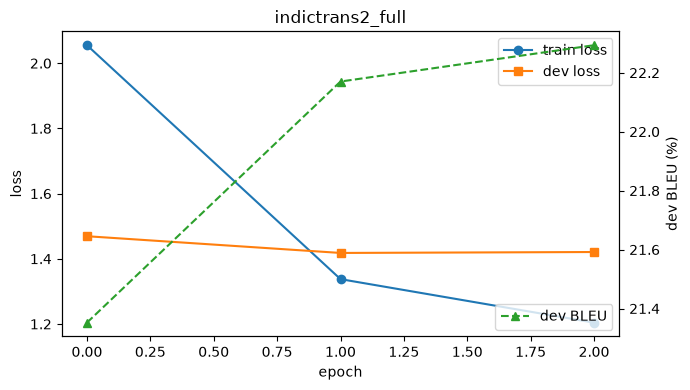

saved ..\artifacts\indictrans2_full\plots\training_curves.png


In [14]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(history["train_loss"], marker="o", label="train loss")
ax1.plot(history["dev_loss"], marker="s", label="dev loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(loc="upper right")
ax2 = ax1.twinx()
ax2.plot([b * 100 for b in history["dev_bleu"]], color="tab:green",
         linestyle="--", marker="^", label="dev BLEU")
ax2.set_ylabel("dev BLEU (%)"); ax2.legend(loc="lower right")
plt.title(cfg.arch_name)
plt.tight_layout()
plot_path = cfg.arch_dir / "plots" / "training_curves.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path, dpi=140)
plt.show()
print(f"saved {plot_path}")

## 10. Test set inference

In [15]:
state = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
missing, unexpected = model.load_state_dict(state["model"], strict=False)
if missing: print(f"warning: {len(missing)} missing keys in checkpoint")
if unexpected: print(f"warning: {len(unexpected)} unexpected keys in checkpoint")

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
elif DEVICE.type == "mps":
    torch.mps.empty_cache()

# warm-up batch so the timer measures steady-state, not the first-call overhead
first_batch = next(iter(test_loader))
_ = generate_batch(model, {"input_ids": first_batch["input_ids"][:2],
                           "attention_mask": first_batch["attention_mask"][:2]})

t0 = time.time()
test_hyps, test_ids = [], []
for batch in tqdm(test_loader, desc=f"beam={cfg.beam_size}"):
    hyps = generate_batch(model, batch)
    test_hyps.extend(hyps)
    test_ids.extend(batch["source_ids"].tolist())
inference_seconds = time.time() - t0
print(f"inference on {len(test_hyps)} sents took {inference_seconds:.2f}s "
      f"({len(test_hyps)/inference_seconds:.2f} sent/sec)")

beam=5:   0%|          | 0/500 [00:00<?, ?it/s]

inference on 1000 sents took 242.82s (4.12 sent/sec)


## 11. Metrics

In [16]:
has_refs = "Sentence_en" in test_df.columns
test_bleu = None
test_bertscore_f1 = None
test_bertscore_f1_unscaled = None
ordered_hyps = []
id_to_hyp = dict(zip(test_ids, test_hyps))
if has_refs:
    ordered_hyps = [id_to_hyp[i] for i in test_df["Source_id"].tolist()]
    refs = test_df["Sentence_en"].tolist()
    test_bleu = bleu_corpus(refs, ordered_hyps)
    print(f"test BLEU (NLTK corpus, default weights) = {test_bleu*100:.2f}")
else:
    print("no test_en.csv found, skipping BLEU / BERTScore")

test BLEU (NLTK corpus, default weights) = 22.22


In [17]:
if has_refs:
    from bert_score import score as bert_score_fn
    _, _, F1_scaled = bert_score_fn(ordered_hyps, refs, lang="en",
                                    rescale_with_baseline=True, verbose=False)
    _, _, F1_raw = bert_score_fn(ordered_hyps, refs, lang="en",
                                 rescale_with_baseline=False, verbose=False)
    test_bertscore_f1 = float(F1_scaled.mean().item())
    test_bertscore_f1_unscaled = float(F1_raw.mean().item())
    print(f"test BERTScore F1 (rescale=True)  = {test_bertscore_f1:.4f}")
    print(f"test BERTScore F1 (rescale=False) = {test_bertscore_f1_unscaled:.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


test BERTScore F1 (rescale=True)  = 0.5793
test BERTScore F1 (rescale=False) = 0.9290


In [18]:
efficiency = {
    "arch": cfg.arch_name,
    "model_name": cfg.model_name,
    "mode": "lora" if cfg.use_lora else "full",
    "device": str(DEVICE),
    "parameters": int(total_params),
    "parameters_million": round(total_params / 1e6, 3),
    "trainable_parameters": int(trainable_params),
    "trainable_parameters_million": round(trainable_params / 1e6, 3),
    "train_seconds": round(train_seconds, 3),
    "inference_seconds": round(inference_seconds, 3),
    "sentences_per_second": round(len(test_hyps) / inference_seconds, 3),
    "best_dev_bleu": round(best_bleu * 100, 3),
}
if test_bleu is not None:
    efficiency["test_bleu"] = round(test_bleu * 100, 3)
if test_bertscore_f1 is not None:
    efficiency["test_bertscore_f1"] = round(test_bertscore_f1, 4)
if test_bertscore_f1_unscaled is not None:
    efficiency["test_bertscore_f1_unscaled"] = round(test_bertscore_f1_unscaled, 4)
efficiency

{'arch': 'indictrans2_full',
 'model_name': 'ai4bharat/indictrans2-indic-en-1B',
 'mode': 'full',
 'device': 'cuda',
 'parameters': 1023006720,
 'parameters_million': 1023.007,
 'trainable_parameters': 1023006720,
 'trainable_parameters_million': 1023.007,
 'train_seconds': 1971.943,
 'inference_seconds': 242.823,
 'sentences_per_second': 4.118,
 'best_dev_bleu': 22.293,
 'test_bleu': 22.217,
 'test_bertscore_f1': 0.5793,
 'test_bertscore_f1_unscaled': 0.929}

## 12. Translation examples

In [19]:
if has_refs:
    step = max(len(test_df) // 8, 1)
    sample_ids = [int(test_df.iloc[i]["Source_id"]) for i in range(0, len(test_df), step)][:8]
    rows = []
    for sid in sample_ids:
        src = test_df.loc[test_df["Source_id"] == sid, "Sentence_sa"].iloc[0]
        ref = test_df.loc[test_df["Source_id"] == sid, "Sentence_en"].iloc[0]
        hyp = id_to_hyp[sid]
        rows.append({
            "id": sid,
            "source": src[:80] + ("..." if len(src) > 80 else ""),
            "reference": ref[:80] + ("..." if len(ref) > 80 else ""),
            "prediction": hyp[:80] + ("..." if len(hyp) > 80 else ""),
        })
    ex_df = pd.DataFrame(rows)
    ex_df.to_csv(cfg.arch_dir / "examples.csv", index=False)
    ex_df
else:
    pd.DataFrame()

## 13. Per-model submission csv

In [20]:
sub = pd.DataFrame({"Source_id": test_ids, "Sentence_en": test_hyps})
sub = sub.sort_values("Source_id").reset_index(drop=True)
assert len(sub) == len(test_df), f"got {len(sub)} predictions, expected {len(test_df)}"
sub_path = cfg.output_dir / f"submission_{cfg.arch_name}.csv"
sub.to_csv(sub_path, index=False, encoding="utf-8")
print(f"wrote {sub_path} with {len(sub)} rows")
sub.head(5)

wrote ..\outputs\submission_indictrans2_full.csv with 1000 rows


,Source_id,Sentence_en
0,1,Eclipse also helps the programmer in error det...
1,2,"""But as it is written I have spoken in the nam..."
2,3,Then it will automatically search for the driv...
3,4,For all iterations i.e. iterator is set for ea...
4,5,"""And I heard that the second beast which he ha..."


## 14. Metrics JSON

In [21]:
metrics_path = cfg.arch_dir / "metrics.json"
metrics_path.write_text(json.dumps(efficiency, indent=2))
print(f"wrote {metrics_path}")

# free GPU memory so the next notebook starts clean
del model
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print(json.dumps(efficiency, indent=2))

wrote ..\artifacts\indictrans2_full\metrics.json


{
  "arch": "indictrans2_full",
  "model_name": "ai4bharat/indictrans2-indic-en-1B",
  "mode": "full",
  "device": "cuda",
  "parameters": 1023006720,
  "parameters_million": 1023.007,
  "trainable_parameters": 1023006720,
  "trainable_parameters_million": 1023.007,
  "train_seconds": 1971.943,
  "inference_seconds": 242.823,
  "sentences_per_second": 4.118,
  "best_dev_bleu": 22.293,
  "test_bleu": 22.217,
  "test_bertscore_f1": 0.5793,
  "test_bertscore_f1_unscaled": 0.929
}
